# Measuring the Influence of Trump's Tweets on Market Volatility and Direction

**Notebook Outline**

- Notebook Setup
- Data Collection
- Sentiment Analysis
- Feature Engineering
- Regression Model

## Notebook Setup

In [1]:
import os
import requests
import zipfile
from dotenv import load_dotenv
import json
import pandas as pd
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

!pip install -q kaggle
!pip install -q statsmodels
!pip install -q matplotlib



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Collection

### Financial Market Data from Yahoo Finance
Using yfinance, Yahoo Finance's API wrapper, we are able to pull historical records of two major indexes. The first, VIX, is an index that attempts to capture volatility by measuring the magnitude of price moevments in the market. The second, SPY, is technically a fund that tracks all the companies in the S&P 500, but is often used as a benchmark to measure "the (U.S.) market" in finance. 


In [2]:
# download() from yfinance pulls in historical records for the specified ticker symbol and date range.

vix = yf.download('^VIX', start='2025-01-01', end='2026-3-31')
spy = yf.download('SPY', start='2025-01-01', end='2026-03-31')


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
vix.head(10)

Price,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,
2025-01-02,17.930000,19.500000,16.959999,17.209999,0
2025-01-03,16.129999,17.940001,16.110001,17.660000,0
2025-01-06,16.040001,16.870001,15.710000,16.770000,0
2025-01-07,17.820000,18.900000,15.790000,16.480000,0
2025-01-08,17.700001,19.500000,17.370001,17.910000,0
2025-01-10,19.540001,20.309999,18.049999,18.290001,0
2025-01-13,19.190001,22.040001,19.150000,21.180000,0
2025-01-14,18.709999,19.660000,18.240000,18.790001,0


In [4]:
spy.head(10)

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2025-01-02,576.280334,582.677525,572.199517,580.962415,50204000
2025-01-03,583.485779,584.126448,578.044689,579.128997,37888500
2025-01-06,586.847107,591.125077,585.112263,587.744129,47679400
2025-01-07,580.213379,589.202970,578.389856,588.877672,60393100
2025-01-08,581.060974,582.135415,576.832338,580.282292,47304700
2025-01-10,572.189636,577.571586,570.277374,577.502580,73105000
2025-01-13,573.076843,573.431681,567.123169,567.537207,47910100
2025-01-14,573.865417,576.635236,570.080298,576.004372,48420600


### Pull Data from Truth Social
This section authenticates access with the GitHub API using a Personal Access Token. With authenticated access, we retrive metadata from the truth_archive.json file from the repository at stiles/trump-truth-social-archive. Then with the direct download URL in the metadata, we download the file into our project. After filtering out duplicates and null values in key rows during the cleaning process, we have a dataframe of 8 columns and ~5,000 rows.

In [5]:
# AUTHENTICATE WITH GITHUB API TO PULL DOWNLOAD URL

load_dotenv()  # Load hiden access token from .env file
ACCESS_TOKEN = os.getenv("GITHUB_TOKEN")

headers = {"Authorization": f"Bearer {ACCESS_TOKEN}"}
url = "https://api.github.com/repos/stiles/trump-truth-social-archive/contents/data/truth_archive.json"

response = requests.get(url, headers=headers) # Make the request to GitHub
print("STATUS:", response.status_code)
data = response.json()


# USING THE AUTHENTICATED URL, DOWNLOAD THE TRUTH SOCIAL DATASET

download_url = data["download_url"] # Pull the download url from the response
file_response = requests.get(download_url)

with open("truth_archive.json", "wb") as f:
    f.write(file_response.content)

print("Truth Social dataset downloaded successfully!")


# LOAD THE TRUTH SOCIAL DATASET INTO A PANDAS DATAFRAME

with open("truth_archive.json", "r", encoding="utf-8") as f:
    truth_data = json.load(f)

truth_df = pd.DataFrame(truth_data)
print(truth_df.shape)
truth_df.head()


STATUS: 200
Truth Social dataset downloaded successfully!
(29469, 8)


,id,created_at,content,url,media,replies_count,reblogs_count,favourites_count
0,116507513607934090,2026-05-02T23:12:54.339Z,"I hate seeing Fox, and other Conservative Outl...",https://truthsocial.com/@realDonaldTrump/11650...,[],3752.0,5482.0,22203.0
1,116507501775457290,2026-05-02T23:09:53.790Z,So ironic that Cryinâ Chuck Schumer and the ...,https://truthsocial.com/@realDonaldTrump/11650...,[],2524.0,7084.0,23750.0
2,116507414650995614,2026-05-02T22:47:44.377Z,I will soon be reviewing the plan that Iran ha...,https://truthsocial.com/@realDonaldTrump/11650...,[],3015.0,5610.0,23285.0
3,116502923327437911,2026-05-02T03:45:32.282Z,,https://truthsocial.com/@realDonaldTrump/11650...,[https://static-assets-1.truthsocial.com/tmtg:...,3204.0,6145.0,31912.0
4,116502906556000308,2026-05-02T03:41:16.371Z,,https://truthsocial.com/@realDonaldTrump/11650...,[https://static-assets-1.truthsocial.com/tmtg:...,865.0,3638.0,22701.0


In [6]:
# CLEAN TRUTH SOCIAL DATA

truth_df = truth_df.dropna(subset=["content"]).copy()

truth_df["created_at"] = pd.to_datetime(
    truth_df["created_at"],
    errors="coerce"
)

truth_df = truth_df.dropna(subset=["content"])      # Key requirement for analysis
truth_df = truth_df.dropna(subset=["created_at"])   # Key requirement for analysis
print(truth_df.shape)

truth_df['date'] = pd.to_datetime(truth_df['created_at']).dt.normalize()

posts = truth_df[truth_df['created_at']>= '2025-01-20'] # Second term inauguration
print(posts.shape)
posts.head(10)

(29469, 8)
(4811, 9)


,id,created_at,content,url,media,replies_count,reblogs_count,favourites_count,date
0,116507513607934090,2026-05-02 23:12:54.339000+00:00,"I hate seeing Fox, and other Conservative Outl...",https://truthsocial.com/@realDonaldTrump/11650...,[],3752.0,5482.0,22203.0,2026-05-02 00:00:00+00:00
1,116507501775457290,2026-05-02 23:09:53.790000+00:00,So ironic that Cryinâ Chuck Schumer and the ...,https://truthsocial.com/@realDonaldTrump/11650...,[],2524.0,7084.0,23750.0,2026-05-02 00:00:00+00:00
2,116507414650995614,2026-05-02 22:47:44.377000+00:00,I will soon be reviewing the plan that Iran ha...,https://truthsocial.com/@realDonaldTrump/11650...,[],3015.0,5610.0,23285.0,2026-05-02 00:00:00+00:00
3,116502923327437911,2026-05-02 03:45:32.282000+00:00,,https://truthsocial.com/@realDonaldTrump/11650...,[https://static-assets-1.truthsocial.com/tmtg:...,3204.0,6145.0,31912.0,2026-05-02 00:00:00+00:00
4,116502906556000308,2026-05-02 03:41:16.371000+00:00,,https://truthsocial.com/@realDonaldTrump/11650...,[https://static-assets-1.truthsocial.com/tmtg:...,865.0,3638.0,22701.0,2026-05-02 00:00:00+00:00
5,116502902374252861,2026-05-02 03:40:12.563000+00:00,"This is what our Country was before, and after...",https://truthsocial.com/@realDonaldTrump/11650...,[https://static-assets-1.truthsocial.com/tmtg:...,2272.0,6451.0,29775.0,2026-05-02 00:00:00+00:00
6,116502893543384666,2026-05-02 03:37:57.815000+00:00,,https://truthsocial.com/@realDonaldTrump/11650...,[https://static-assets-1.truthsocial.com/tmtg:...,1390.0,3424.0,20605.0,2026-05-02 00:00:00+00:00
7,116502871108388206,2026-05-02 03:32:15.483000+00:00,,https://truthsocial.com/@realDonaldTrump/11650...,[https://static-assets-1.truthsocial.com/tmtg:...,925.0,4152.0,26079.0,2026-05-02 00:00:00+00:00
8,116502848851907459,2026-05-02 03:26:35.877000+00:00,,https://truthsocial.com/@realDonaldTrump/11650...,[https://static-assets-1.truthsocial.com/tmtg:...,2445.0,5879.0,30410.0,2026-05-02 00:00:00+00:00
9,116502833969390552,2026-05-02 03:22:48.789000+00:00,,https://truthsocial.com/@realDonaldTrump/11650...,[https://static-assets-1.truthsocial.com/tmtg:...,1096.0,3913.0,22643.0,2026-05-02 00:00:00+00:00


### Pull Data from Kaggle
In this section we make an authenticated call to the Kaggle API. With access we pull truth social data from Kaggle and compare with the GitHub file. Note that while the dataste is named 'trump_tweets_data' we filter for only Truth Social data during the cleaning process. The result is a dataset of 18 columns and ~6,200 rows. We chose to move forward with the data from Kaggle.

In [7]:
# AUTHENTICATE WITH KAGGLE API

load_dotenv()  # Load hiden access token from .env file
KAGGLE_USERNAME = os.getenv("KAGGLE_USERNAME")
KAGGLE_KEY = os.getenv("KAGGLE_KEY")

kaggle_dir = os.path.expanduser("~/.kaggle") # Creates a hidden directory required for storing API credentials
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_path = os.path.join(kaggle_dir, "kaggle.json")

if os.path.exists(kaggle_path):   
    print("kaggle.json already exists — skipping creation.") # Avoid overwriting existing credentials
    
else:
    kaggle_credentials = {
        "username": KAGGLE_USERNAME,
        "key": KAGGLE_KEY
    }
    with open(kaggle_path, "w") as f:
        json.dump(kaggle_credentials, f)

    print("kaggle.json created successfully!")


# USING THE AUTHENTICATED KAGGLE API, DOWNLOAD THE TRUMP TWEETS DATASET

!kaggle datasets download -d datadrivendecision/trump-tweets-2009-2025

zip_path = "trump-tweets-2009-2025.zip"
extract_path = "trump_tweets_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

# Check which files are inside
files = os.listdir(extract_path)
print(files)

# Load the CSV file
csv_path = os.path.join(extract_path, files[0])
df = pd.read_csv(csv_path)


# CLEAN KAGGLE TRUMP TWEETS DATA

df = df.dropna(subset=["text"]).copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
Kaggle_df = df[df['platform'] != "Twitter"]
Posts_df_kaggle = Kaggle_df[Kaggle_df['date'] >= '2025-01-20'] # Second term inauguration

print(Posts_df_kaggle.shape)
Posts_df_kaggle


kaggle.json already exists — skipping creation.
Dataset URL: https://www.kaggle.com/datasets/datadrivendecision/trump-tweets-2009-2025
License(s): CC0-1.0
trump-tweets-2009-2025.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset extracted successfully!
['djt_posts_dec2025.csv']
(6212, 18)


,id,date,platform,handle,text,favorite_count,repost_count,quote_flag,repost_flag,deleted_flag,word_count,hashtags,urls,user_mentions,media_count,media_urls,post_url,in_reply_to
0,115816402893182666,2025-12-31 21:54:21+00:00,Truth Social,realDonaldTrump,"Good News! George and Amal Clooney, two of the...",52,16,False,False,False,144,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
1,115816171466225987,2025-12-31 20:55:30+00:00,Truth Social,realDonaldTrump,We are removing the National Guard from Chicag...,44,16,False,False,False,107,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
2,115816098525451632,2025-12-31 20:36:57+00:00,Truth Social,realDonaldTrump,The Democrats are a bunch of cheaters and thie...,461,179,False,False,False,50,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
3,115816063544553030,2025-12-31 20:28:03+00:00,Truth Social,realDonaldTrump,Republicans: No more money to Fat Cat Insuranc...,309,97,False,False,False,24,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
4,115815971019162695,2025-12-31 20:04:31+00:00,Truth Social,realDonaldTrump,The United States has set a World Record on in...,36,11,False,False,False,76,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6344,113860871478605894,2025-01-20 13:17:00+00:00,Truth Social,realDonaldTrump,[Video],132,35,False,False,False,1,NaN,NaN,NaN,1,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
6345,113858887952515391,2025-01-20 04:52:34+00:00,Truth Social,realDonaldTrump,RT @TeamTrump President Trump delivers remarks...,1179,294,False,True,False,18,NaN,NaN,NaN,1,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
6346,113858887611739292,2025-01-20 04:52:28+00:00,Truth Social,realDonaldTrump,RT @TeamTrump The sacrifice of these American ...,1080,199,False,True,False,18,NaN,NaN,NaN,4,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
6347,113858887418016610,2025-01-20 04:52:26+00:00,Truth Social,realDonaldTrump,"RT @TeamTrump Today, President Donald J. Trump...",917,170,False,True,False,20,NaN,NaN,NaN,4,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN


## Sentiment Analysis
In our case, the raw text data isn't very valuable for regression. So in this section, we transform the text values into quantitative measures of sentiment using tools from VADER (Valence Aware Dictionary and sEntiment Reasoner), a rule-based NLP tool designed for social media text.

Each post gets a compound score from -1 (very negative) to +1 (very positive). For example:

"I am on my way to Malaysia, where I will sign..." → +0.97 (very positive)

"Canada was caught red-handed..." → -0.83 (very negative)

Posts that are just URLs → 0.00 (neutral, no text to analyze)



In [8]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    return pd.Series({
        'compound': scores['compound'],  # overall score: -1 (negative) to +1 (positive)
        'positive': scores['pos'],
        'negative': scores['neg'],
        'neutral':  scores['neu']
    })

sentiment_scores = posts['content'].apply(get_sentiment)
posts = pd.concat([posts, sentiment_scores], axis=1)

print(posts[['date', 'content', 'compound', 'positive', 'negative']].head())
print(posts.shape)

                       date  \
0 2026-05-02 00:00:00+00:00   
1 2026-05-02 00:00:00+00:00   
2 2026-05-02 00:00:00+00:00   
3 2026-05-02 00:00:00+00:00   
4 2026-05-02 00:00:00+00:00   

                                             content  compound  positive  \
0  I hate seeing Fox, and other Conservative Outl...   -0.9980     0.033   
1  So ironic that Cryinâ Chuck Schumer and the ...   -0.7910     0.115   
2  I will soon be reviewing the plan that Iran ha...    0.7704     0.119   
3                                                       0.0000     0.000   
4                                                       0.0000     0.000   

   negative  
0     0.230  
1     0.152  
2     0.000  
3     0.000  
4     0.000  
(4811, 13)


## Feature Engineering
In this section, we transform our collected data so that is is more meaningful to our model, we align the various collections to fit together in a dataset, and build experiemental features. 

Aggregated posts to the daily level and created these features:

| Feature                      | What it measures                                |
| ---------------------------- | ----------------------------------------------- |
| tweet_volume                 | How many posts Trump made that day              |
| avg_sentiment                | Average positivity/negativity of posts that day |
| neg_ratio                    | Proportion of posts with negative tone          |
| avg_favourites / avg_reblogs | Engagement per post                             |

In [9]:
daily_tweets = posts.groupby('date').agg(
    tweet_volume    = ('content', 'count'),
    avg_sentiment   = ('compound', 'mean'),
    neg_ratio       = ('negative', 'mean'),
    avg_favourites  = ('favourites_count', 'mean'),
    avg_reblogs     = ('reblogs_count', 'mean')
).reset_index()

print(daily_tweets.head())
print(daily_tweets.shape)

                       date  tweet_volume  avg_sentiment  neg_ratio  \
0 2025-01-20 00:00:00+00:00             4       0.330225   0.015250   
1 2025-01-21 00:00:00+00:00            22       0.158291   0.021909   
2 2025-01-22 00:00:00+00:00            11       0.090591   0.041818   
3 2025-01-23 00:00:00+00:00            12       0.350342   0.033333   
4 2025-01-24 00:00:00+00:00             8       0.294725   0.007125   

   avg_favourites  avg_reblogs  
0    15352.750000  4258.000000  
1    16698.500000  3459.227273  
2    34435.636364  6916.000000  
3    31431.750000  6549.666667  
4    26101.250000  5425.125000  
(284, 6)


### Merged with financial data on date, giving 193 matched trading days.

In [10]:
# Flatten yfinance multi-level columns
spy_close = spy['Close'].squeeze()
vix_close = vix['Close'].squeeze()

df = pd.DataFrame()
df['SPY_Returns'] = spy_close.pct_change()
df['VIX_Returns'] = vix_close.pct_change()
df['VIX_Level']   = vix_close
df.index = pd.to_datetime(df.index).normalize()
df = df.reset_index().rename(columns={'Date': 'date'})

# Strip timezone info from both sides before merging
df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
daily_tweets['date'] = pd.to_datetime(daily_tweets['date']).dt.tz_localize(None)

# print(df['date'])
# print(daily_tweets['date'])

# Merge on date
merged = pd.merge(df, daily_tweets, on='date', how='inner')
merged = merged.dropna()

print(merged.shape)
print(merged.head())
print(merged.shape)

(193, 9)
        date  SPY_Returns  VIX_Returns  VIX_Level  tweet_volume  \
0 2025-01-21     0.009153    -0.056982      15.06            22   
1 2025-01-22     0.005622     0.002656      15.10            11   
2 2025-01-23     0.005458    -0.005298      15.02            12   
3 2025-01-24    -0.002919    -0.011318      14.85             8   
4 2025-01-27    -0.014145     0.205387      17.90             9   

   avg_sentiment  neg_ratio  avg_favourites  avg_reblogs  
0       0.158291   0.021909    16698.500000  3459.227273  
1       0.090591   0.041818    34435.636364  6916.000000  
2       0.350342   0.033333    31431.750000  6549.666667  
3       0.294725   0.007125    26101.250000  5425.125000  
4       0.365544   0.000000    35103.555556  6105.444444  
(193, 9)


## Estimation Model
This section implements our framework for quantifying the relationship between tweet-derived features and stock market outcomes.

In [11]:
# Lag tweet features by 1 day (yesterday's posts → today's market)
merged['lag_sentiment']  = merged['avg_sentiment'].shift(1)
merged['lag_volume']     = merged['tweet_volume'].shift(1)
merged['lag_neg_ratio']  = merged['neg_ratio'].shift(1)

# Rolling 7-day average sentiment (captures sustained tone)
merged['rolling_sentiment'] = merged['avg_sentiment'].rolling(7).mean()

merged = merged.dropna()
print(f"Final dataset: {merged.shape[0]} observations")

Final dataset: 187 observations


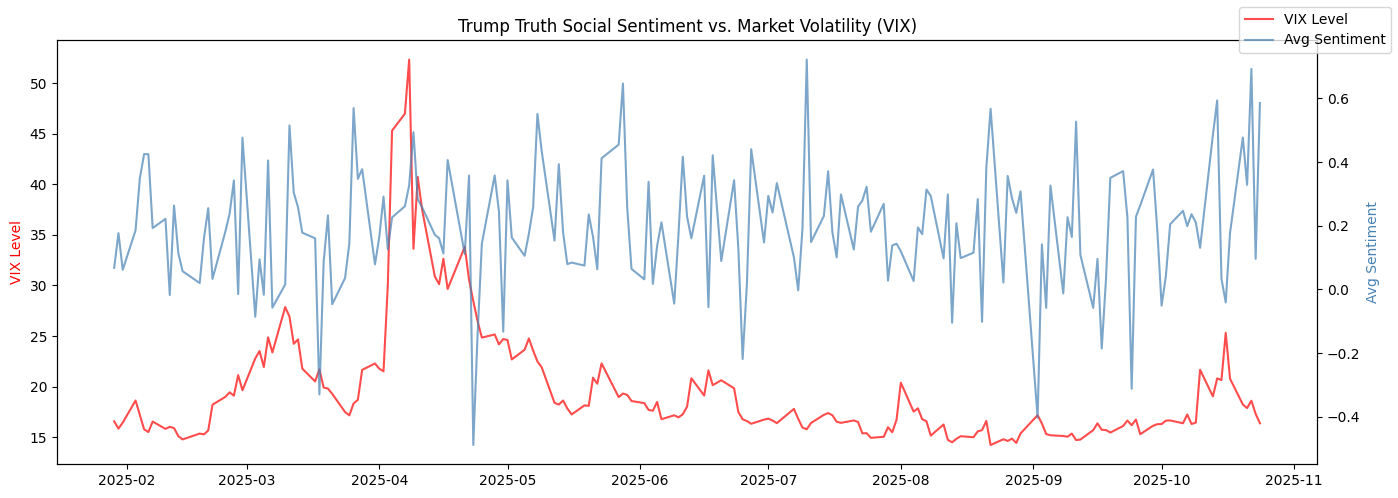

In [12]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(merged['date'], merged['VIX_Level'], color='red', alpha=0.7, label='VIX Level')
ax2.plot(merged['date'], merged['avg_sentiment'], color='steelblue', alpha=0.7, label='Avg Sentiment')

ax1.set_ylabel('VIX Level', color='red')
ax2.set_ylabel('Avg Sentiment', color='steelblue')
ax1.set_title("Trump Truth Social Sentiment vs. Market Volatility (VIX)")
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Lagged Variables 
Instead of using today's sentiment to predict today's market, we used yesterday's sentiment to predict today's market.

Why? Because if we used same day data, we can't tell whether:

Trump's posts caused markets to move, OR markets moving caused Trump to post more/differently

In [13]:
import statsmodels.formula.api as smf

# Model 1: VIX returns ~ lagged sentiment + lagged volume
model_vix = smf.ols('VIX_Returns ~ lag_sentiment + lag_volume + lag_neg_ratio', 
                     data=merged).fit()
print(model_vix.summary())


                            OLS Regression Results                            
Dep. Variable:            VIX_Returns   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.434
Date:                Sat, 06 Jun 2026   Prob (F-statistic):              0.234
Time:                        19:54:03   Log-Likelihood:                 182.02
No. Observations:                 187   AIC:                            -356.0
Df Residuals:                     183   BIC:                            -343.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0330      0.022      1.505

In [14]:
# Model 2: SPY returns ~ lagged sentiment + lagged volume
model_spy = smf.ols('SPY_Returns ~ lag_sentiment + lag_volume + lag_neg_ratio', 
                     data=merged).fit()
print(model_spy.summary())

                            OLS Regression Results                            
Dep. Variable:            SPY_Returns   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.7651
Date:                Sat, 06 Jun 2026   Prob (F-statistic):              0.515
Time:                        19:54:04   Log-Likelihood:                 542.38
No. Observations:                 187   AIC:                            -1077.
Df Residuals:                     183   BIC:                            -1064.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0010      0.003      0.329

### Remove the effect of market autocorrelation

Financial markets don't move randomly day to day. If the VIX was high yesterday, it tends to stay somewhat high today. If the S&P 500 dropped yesterday, it often continues dropping (or bounces back) today regardless of anything Trump posts, so we had to add that to reduce bias, (Trump comments on market being bad, and market stays bad, but that is something that would've happened without the interference of Trump).

In [15]:
# Add lagged market controls to reduce omitted variable bias
merged['lag_SPY_Returns'] = merged['SPY_Returns'].shift(1)
merged['lag_VIX_Level']   = merged['VIX_Level'].shift(1)
merged = merged.dropna()

model_vix_controlled = smf.ols(
    'VIX_Returns ~ lag_sentiment + lag_volume + lag_neg_ratio + lag_VIX_Level + lag_SPY_Returns',
    data=merged).fit()
print(model_vix_controlled.summary())

                            OLS Regression Results                            
Dep. Variable:            VIX_Returns   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1.890
Date:                Sat, 06 Jun 2026   Prob (F-statistic):             0.0981
Time:                        19:54:04   Log-Likelihood:                 183.15
No. Observations:                 186   AIC:                            -354.3
Df Residuals:                     180   BIC:                            -334.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0710      0.031     

## Lead-Lag Placebo Test

To strengthen the causal interpretation of our results, we perform a lead-lag placebo test inspired by the event-study framework discussed in class.

The objective is to assess whether the relationship between Trump's Truth Social sentiment and market outcomes follows the expected temporal ordering. If sentiment influences financial markets, then past sentiment should help explain future market movements. However, future sentiment should not be able to predict current market outcomes.

To test this, we construct:
- **Lag 1 sentiment**: sentiment from one day earlier.
- **Lag 2 sentiment**: sentiment from two days earlier.
- **Lag 3 sentiment**: sentiment from three days earlier.
- **Lead 1 sentiment**: sentiment from one day in the future (placebo variable).

We then estimate separate regression models for VIX returns and SPY returns.

The lead variable serves as a placebo test. Since future sentiment cannot causally affect current market outcomes, a statistically significant coefficient on the lead variable would suggest that the observed relationship may be driven by omitted variables, common trends, or spurious correlation rather than a causal effect.

If the lagged sentiment variables are significant while the lead variable remains insignificant, this strengthens the credibility of our estimation strategy and supports the proposed causal mechanism.

In [19]:
import statsmodels.formula.api as smf

# Create lagged sentiment variables
merged["sentiment_lag1"] = merged["avg_sentiment"].shift(1)
merged["sentiment_lag2"] = merged["avg_sentiment"].shift(2)
merged["sentiment_lag3"] = merged["avg_sentiment"].shift(3)

# Create lead sentiment variable/placebo
merged["sentiment_lead1"] = merged["avg_sentiment"].shift(-1)

# Drop rows created by shifting
lead_lag_data = merged.dropna(
    subset=[
        "sentiment_lag1",
        "sentiment_lag2",
        "sentiment_lag3",
        "sentiment_lead1",
        "VIX_Returns",
        "SPY_Returns"
    ]
)

# Lead-lag placebo test for VIX
model_vix_leadlag = smf.ols(
    "VIX_Returns ~ sentiment_lag1 + sentiment_lag2 + sentiment_lag3 + sentiment_lead1",
    data=lead_lag_data
).fit()

print(model_vix_leadlag.summary())

# Lead-lag placebo test for SPY
model_spy_leadlag = smf.ols(
    "SPY_Returns ~ sentiment_lag1 + sentiment_lag2 + sentiment_lag3 + sentiment_lead1",
    data=lead_lag_data
).fit()

print(model_spy_leadlag.summary())

                            OLS Regression Results                            
Dep. Variable:            VIX_Returns   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     1.962
Date:                Sat, 06 Jun 2026   Prob (F-statistic):              0.102
Time:                        19:57:18   Log-Likelihood:                 177.86
No. Observations:                 182   AIC:                            -345.7
Df Residuals:                     177   BIC:                            -329.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0072      0.016     

## Interpretation of Results

The key coefficient of interest in this robustness test is the coefficient on **sentiment_lead1**.

- If **sentiment_lead1 is statistically insignificant (p > 0.05)**, future sentiment does not predict current market outcomes. This supports the assumed temporal ordering and strengthens the causal interpretation of the main results.

- If **sentiment_lead1 is statistically significant (p < 0.05)**, future sentiment appears to predict current market outcomes. Because future events cannot causally influence the past, this would suggest the presence of omitted variables, common trends, or spurious correlation, weakening the causal interpretation of the findings.

The lagged sentiment coefficients provide additional evidence regarding how long any market response persists following Truth Social activity.